<a href="https://colab.research.google.com/github/lethienan7407-gif/BTCK/blob/main/KTHP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing import image_dataset_from_directory
import os


IMG_SIZE = (224, 224)
BATCH_SIZE = 32
CHANNELS = 3
DATA_DIR = "/content/drive/MyDrive/AI"
EPOCHS_STAGE_1 = 30
EPOCHS_STAGE_2 = 100


train_dataset = image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="training", seed=42,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical',
    crop_to_aspect_ratio=True
)

val_dataset = image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="validation", seed=42,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical',
    crop_to_aspect_ratio=True
)

num_classes = len(train_dataset.class_names)


AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)


base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(IMG_SIZE[0], IMG_SIZE[1], CHANNELS))
base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], CHANNELS))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)


os.makedirs("saved_models", exist_ok=True)
callbacks_list = [
    tf.keras.callbacks.ModelCheckpoint(filepath="saved_models/best_food_model.keras", monitor="val_loss", save_best_only=True, mode="min", verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)
]


model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
print("\n--- [STAGE 1] BẮT ĐẦU RUN ---")
model.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS_STAGE_1, callbacks=callbacks_list)

Found 6681 files belonging to 11 classes.
Using 5345 files for training.
Found 6681 files belonging to 11 classes.
Using 1336 files for validation.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- [STAGE 1] BẮT ĐẦU RUN ---
Epoch 1/30
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.6165 - loss: 1.3099
Epoch 1: val_loss improved from None to 0.36502, saving model to saved_models/best_food_model.keras

Epoch 1: finished saving model to saved_models/best_food_model.keras
168/168 ━━━━━━━━━━━━━━━━━━━━ 353s 1s/step - accuracy: 0.7936 - loss: 0.8149 - val_accuracy: 0.9199 - val_loss: 0.3650
Epoch 2/30
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9177 - loss: 0.3273
Epoch 2: val_loss improved from 0.36502 to 0.24510, saving model to saved_models/best_food_model.keras

Epoch 2: finished saving model to saved_models/best_food_model.keras
168/168 ━━━━━━━━━━━━━━━━━━━━ 31s 73ms/step - accuracy: 0.9225 - loss: 0.3060 - val_accuracy: 0.9386 - val_loss: 0.2451
Epoch 3/30
168/

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Re-create a temporary dataset object to retrieve class names.
# This assumes DATA_DIR, IMG_SIZE, and BATCH_SIZE are still in scope
# from previous cells, which they are in this notebook's context.
# Note: For better efficiency, it is recommended to store class_names
# in a separate variable right after the initial image_dataset_from_directory call.
temp_raw_dataset = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE, # batch_size doesn't strictly matter for just getting names
    label_mode='categorical',
    crop_to_aspect_ratio=True,
    shuffle=False # No need to shuffle if only getting class names
)
print(temp_raw_dataset.class_names)

Found 6681 files belonging to 11 classes.
Using 5345 files for training.
['ca_hu_kho', 'canh_chua_co_ca', 'canh_chua_khong_ca', 'canh_rau', 'com_trang', 'dau_hu_sot_ca', 'rau_xao', 'suon_nuong', 'thit_kho', 'thit_kho_hot_vit', 'trung_chien']


Đang tải mô hình...
Tải mô hình thành công!

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step

[KẾT QUẢ]: AI nhận diện đây là món: ==> THIT_KHO <==
[ĐỘ TỰ TIN]: 99.89%


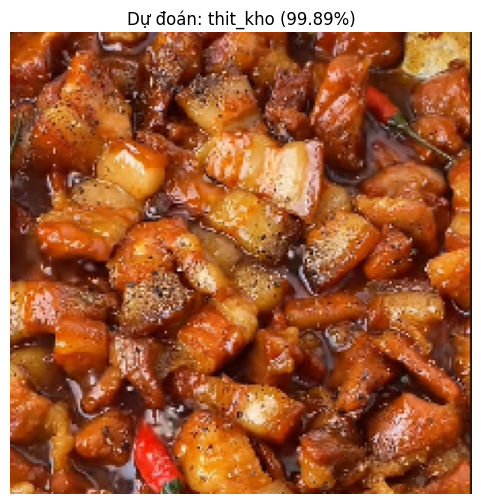

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# ==========================================
# 1. CẤU HÌNH THÔNG SỐ TEST
# ==========================================
# Nhớ cài đặt kích thước CHÍNH XÁC giống lúc bạn train (224, 224)
IMG_SIZE = (224, 224)

# Đường dẫn tới file mô hình đã được lưu sau khi train
MODEL_PATH = "saved_models/best_food_model.keras"

# Đường dẫn tới tấm ảnh món ăn bạn muốn test thử
IMAGE_TO_TEST = "/content/26f008d9-888d-4566-bea2-1a95e715dd76.jfif" # Thay bằng ảnh món ăn bất kỳ của bạn

# Danh sách tên các món ăn (Phải đúng THỨ TỰ và ĐẦY ĐỦ các thư mục lúc train)
# Ví dụ lúc train bạn có 11 thư mục món ăn, hãy điền đủ 11 tên vào đây:
CLASS_NAMES = ['ca_hu_kho', 'canh_chua_co_ca', 'canh_chua_khong_ca', 'canh_rau', 'com_trang', 'dau_hu_sot_ca', 'rau_xao', 'suon_nuong', 'thit_kho', 'thit_kho_hot_vit', 'trung_chien'] # ... Điền đủ các món của bạn

# ==========================================
# 2. LOAD MÔ HÌNH VÀ XỬ LÝ ẢNH
# ==========================================
print("Đang tải mô hình...")
model = tf.keras.models.load_model(MODEL_PATH)
print("Tải mô hình thành công!\n")

# Đọc ảnh và resize tự động về đúng chuẩn của mạng
img = image.load_img(IMAGE_TO_TEST, target_size=IMG_SIZE)
img_array = image.img_to_array(img)

# Thêm một chiều (dimension) để biến ảnh thành một Batch gồm 1 ảnh: (1, 224, 224, 3)
img_batch = np.expand_dims(img_array, axis=0)

# ==========================================
# 3. TIẾN HÀNH DỰ ĐOÁN (PREDICT)
# ==========================================
predictions = model.predict(img_batch)

# Lấy chỉ số (index) của món ăn có xác suất cao nhất
predicted_class_idx = np.argmax(predictions[0])
predicted_class_name = CLASS_NAMES[predicted_class_idx]

# Tính toán độ tự tin (Độ chính xác mà AI tin tưởng vào kết quả đó)
confidence = predictions[0][predicted_class_idx] * 100

print(f"\n[KẾT QUẢ]: AI nhận diện đây là món: ==> {predicted_class_name.upper()} <==")
print(f"[ĐỘ TỰ TIN]: {confidence:.2f}%")

# ==========================================
# 4. HIỂN THỊ ẢNH KÈM KẾT QUẢ DỰ ĐOÁN
# ==========================================
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Dự đoán: {predicted_class_name} ({confidence:.2f}%)")
plt.axis('off')
plt.show()

In [ ]:
model.save("drive/MyDrive/AI_model/final_food_model.keras")
print("Đã lưu bản sao mô hình cuối cùng vào Google Drive!")

Đã lưu bản sao mô hình cuối cùng vào Google Drive!


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đang tải mô hình từ Google Drive...
Tải mô hình THÀNH CÔNG!



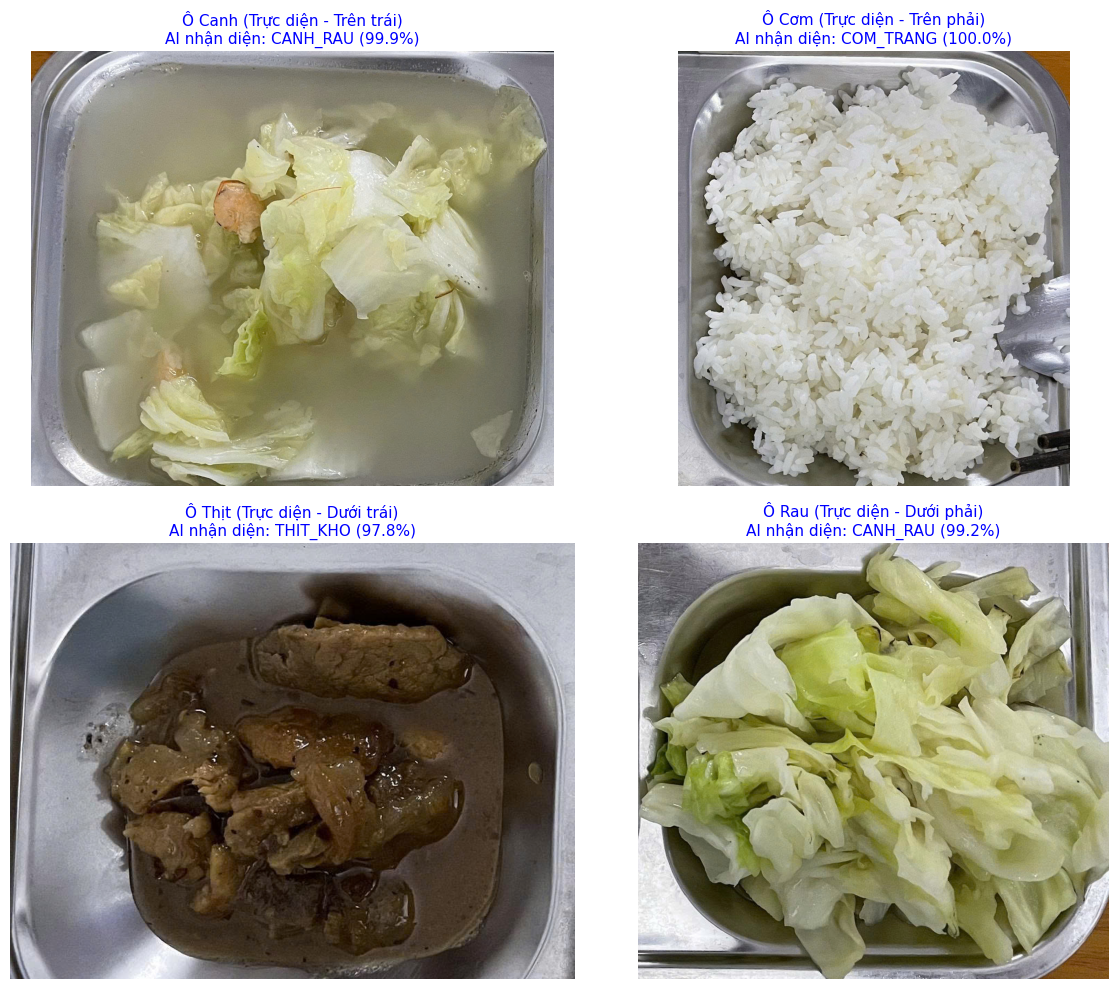

In [ ]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os

# ==========================================
# 1. KẾT NỐI DRIVE & ĐỊNH NGHĨA ĐƯỜNG DẪN
# ==========================================
# Kết nối Colab với Google Drive để lấy file mô hình
from google.colab import drive
drive.mount('/content/drive')

# Đường dẫn CHUẨN đến file mô hình bạn vừa lưu trên Drive
MODEL_PATH = "drive/MyDrive/AI_model/final_food_model.keras"

# Đường dẫn tới tấm ảnh khay cơm bạn tải lên Colab để test
# (Bạn có thể tải ảnh khay cơm lên thanh công cụ bên trái rồi copy đường dẫn dán vào đây)
IMAGE_PATH = "/content/khay.jpg"

# Kích thước ảnh đầu vào (Trùng với kích thước 224x224 của bản train gần nhất)
IMG_SIZE = (224, 224)

# Danh sách 11 món ăn của bạn (Nhớ xếp đúng thứ tự bảng chữ cái giống lúc train)
CLASS_NAMES = ['ca_hu_kho', 'canh_chua_co_ca', 'canh_chua_khong_ca', 'canh_rau', 'com_trang', 'dau_hu_sot_ca', 'rau_xao', 'suon_nuong', 'thit_kho', 'thit_kho_hot_vit', 'trung_chien'] # <-- Thay thế/bổ sung đủ tên 11 món của bạn vào đây

# ==========================================
# 2. KIỂM TRA VÀ TẢI MÔ HÌNH
# ==========================================
if not os.path.exists(MODEL_PATH):
    print(f"[LỖI] Không tìm thấy file mô hình tại: {MODEL_PATH}")
    print("Hãy chắc chắn bạn đã gõ đúng tên thư mục (AI_model) và tên file.")
else:
    print("Đang tải mô hình từ Google Drive...")
    model = tf.keras.models.load_model(MODEL_PATH)
    print("Tải mô hình THÀNH CÔNG!\n")

    # Đọc ảnh khay cơm gốc
    img_bgr = cv2.imread(IMAGE_PATH)
    if img_bgr is None:
        print(f"[LỖI] Không tìm thấy hoặc không đọc được ảnh khay cơm tại: {IMAGE_PATH}")
    else:
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        h, w, _ = img_rgb.shape

        # ==========================================
        # 3. ĐỊNH NGHĨA TỌA ĐỘ CẮT THEO TỶ LỆ (%) KHAY CƠM
        # ==========================================
        boxes = {
            "Ô Canh (Trực diện - Trên trái)": [int(0.02*h), int(0.05*w), int(0.52*h), int(0.50*w)],
            "Ô Cơm (Trực diện - Trên phải)":  [int(0.02*h), int(0.60*w), int(0.54*h), int(0.95*w)],
            "Ô Thịt (Trực diện - Dưới trái)": [int(0.55*h), int(0.03*w), int(0.88*h), int(0.35*w)],
            "Ô Rau (Trực diện - Dưới phải)":  [int(0.55*h), int(0.63*w), int(0.97*h), int(0.97*w)]
        }

        # Khởi tạo khung hiển thị kết quả các ô cắt
        plt.figure(figsize=(12, 10))

        # ==========================================
        # 4. VÒNG LẶP CẮT ẢNH VÀ ĐƯA VÀO AI NHẬN DIỆN
        # ==========================================
        for i, (name, box) in enumerate(boxes.items(), 1):
            ymin, xmin, ymax, xmax = box

            # Tiến hành cắt (Crop) vùng thức ăn riêng lẻ
            crop_img = img_rgb[ymin:ymax, xmin:xmax]

            # Xử lý ảnh thích ứng kích thước đầu vào CNN
            img_resized = cv2.resize(crop_img, IMG_SIZE)
            img_batch = np.expand_dims(img_resized, axis=0)

            # Thực hiện dự đoán nhãn món ăn
            predictions = model.predict(img_batch, verbose=0)
            predicted_idx = np.argmax(predictions[0])
            predicted_label = CLASS_NAMES[predicted_idx]
            confidence = predictions[0][predicted_idx] * 100

            # Vẽ hình ảnh minh họa kết quả từng ô ra màn hình đồ họa
            plt.subplot(2, 2, i)
            plt.imshow(crop_img)
            plt.title(f"{name}\nAI nhận diện: {predicted_label.upper()} ({confidence:.1f}%)", fontsize=11, color='blue')
            plt.axis('off')

        plt.tight_layout()
        plt.show()

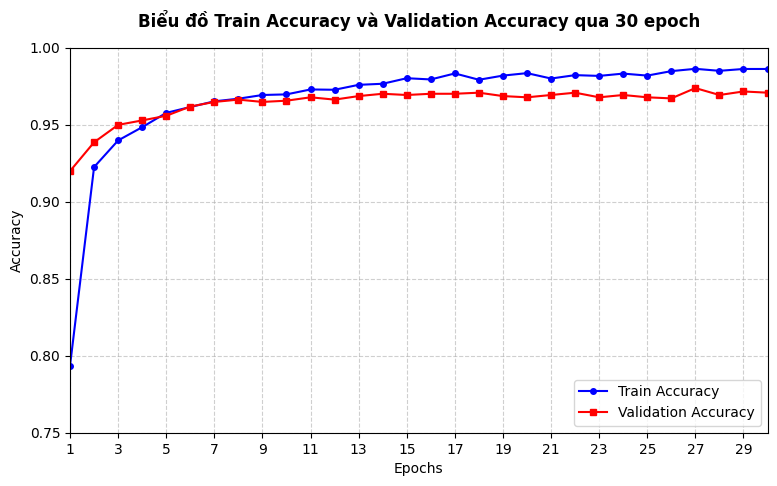

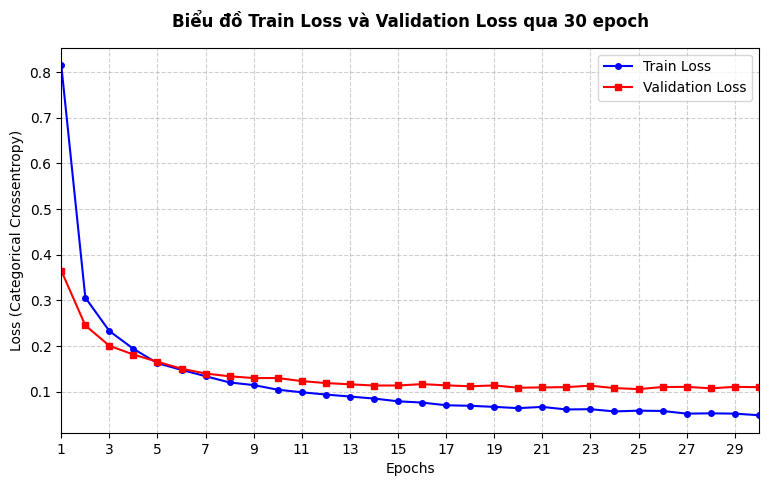

In [1]:
import matplotlib.pyplot as plt

# 1. Trích xuất chính xác dữ liệu từ log thực nghiệm của bạn
epochs = list(range(1, 31))

train_acc = [
    0.7936, 0.9225, 0.9398, 0.9484, 0.9577, 0.9615, 0.9652, 0.9669, 0.9693, 0.9697,
    0.9729, 0.9727, 0.9759, 0.9766, 0.9802, 0.9794, 0.9833, 0.9792, 0.9819, 0.9835,
    0.9800, 0.9822, 0.9817, 0.9832, 0.9819, 0.9848, 0.9863, 0.9850, 0.9862, 0.9862
]

val_acc = [
    0.9199, 0.9386, 0.9499, 0.9528, 0.9558, 0.9618, 0.9648, 0.9663, 0.9648, 0.9656,
    0.9678, 0.9663, 0.9686, 0.9701, 0.9693, 0.9701, 0.9701, 0.9708, 0.9686, 0.9678,
    0.9693, 0.9708, 0.9678, 0.9693, 0.9678, 0.9671, 0.9738, 0.9693, 0.9716, 0.9708
]

train_loss = [
    0.8149, 0.3060, 0.2329, 0.1939, 0.1625, 0.1479, 0.1340, 0.1203, 0.1146, 0.1045,
    0.0988, 0.0939, 0.0895, 0.0851, 0.0791, 0.0763, 0.0704, 0.0692, 0.0669, 0.0641,
    0.0668, 0.0612, 0.0618, 0.0569, 0.0586, 0.0579, 0.0521, 0.0527, 0.0521, 0.0486
]

val_loss = [
    0.3650, 0.2451, 0.2007, 0.1814, 0.1656, 0.1504, 0.1399, 0.1338, 0.1300, 0.1300,
    0.1233, 0.1190, 0.1163, 0.1136, 0.1137, 0.1167, 0.1140, 0.1120, 0.1138, 0.1088,
    0.1095, 0.1101, 0.1133, 0.1080, 0.1058, 0.1103, 0.1107, 0.1075, 0.1106, 0.1101
]

# --- VẼ BIỂU ĐỒ 1: ACCURACY (Cho mục màu vàng) ---
plt.figure(figsize=(9, 5))
plt.plot(epochs, train_acc, color='blue', linestyle='-', marker='o', markersize=4, label='Train Accuracy')
plt.plot(epochs, val_acc, color='red', linestyle='-', marker='s', markersize=4, label='Validation Accuracy')
plt.title('Biểu đồ Train Accuracy và Validation Accuracy qua 30 epoch', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Accuracy', fontsize=10)
plt.xlim(1, 30)
plt.ylim(0.75, 1.0)
plt.xticks(range(1, 31, 2))
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('train_val_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*50 + "\n")

# --- VẼ BIỂU ĐỒ 2: LOSS (Cho mục 4.3 Giá trị mất mát) ---
plt.figure(figsize=(9, 5))
plt.plot(epochs, train_loss, color='blue', linestyle='-', marker='o', markersize=4, label='Train Loss')
plt.plot(epochs, val_loss, color='red', linestyle='-', marker='s', markersize=4, label='Validation Loss')
plt.title('Biểu đồ Train Loss và Validation Loss qua 30 epoch', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss (Categorical Crossentropy)', fontsize=10)
plt.xlim(1, 30)
plt.xticks(range(1, 31, 2))
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('train_val_loss.png', dpi=300, bbox_inches='tight')
plt.show()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# --- BƯỚC 1: DỰ ĐOÁN VÀ TÍNH MA TRẬN NHẦM LẪN ---
# Thường bạn cần load mô hình tốt nhất đã lưu trước đó:
# model = tf.keras.models.load_model("saved_models/best_food_model.keras")

# Lấy nhãn thực tế (True Labels) và nhãn dự đoán (Predicted Labels) từ tập test/validation
y_true = []
y_pred = []

# Duyệt qua tập validation/test để thu thập kết quả
for images, labels in val_dataset: # Thay val_dataset bằng test_dataset nếu bạn có tập test riêng
    preds = model.predict(images, verbose=0)

    # Đối với nhãn dạng categorical (one-hot encoding), dùng argmax để lấy chỉ số lớp
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Tính toán ma trận nhầm lẫn
cm = confusion_matrix(y_true, y_pred)

# Lấy danh sách tên các món ăn (11 lớp) theo đúng thứ tự sắp xếp của Dataset
class_names = train_dataset.class_names

# --- BƯỚC 2: VẼ HEATMAP BẰNG SEABORN ---
# Thiết lập kích thước lớn (12x10 hoặc lớn hơn) để tránh bị đè chữ chữ khi chèn nguyên trang Word
plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,            # Hiện số lượng mẫu cụ thể vào từng ô
    fmt='d',               # Định dạng số nguyên (integer)
    cmap='Blues',          # Bảng màu xanh dương (đậm dần theo số lượng lớn)
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True,             # Hiển thị thanh đo màu sắc ở bên cạnh
    square=True            # Giữ các ô ở dạng hình vuông chuẩn
)

# Cấu hình tiêu đề và nhãn các trục
plt.title('Ma trận nhầm lẫn (Confusion Matrix) trên tập dữ liệu kiểm hoạch', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Nhãn dự đoán (Predicted Label)', fontsize=12, fontweight='bold', labelpad=15)
plt.ylabel('Nhãn thực tế (True Label)', fontsize=12, fontweight='bold', labelpad=15)

# Xoay chữ nhãn trục X một góc 45 độ để tên các món ăn không bị chồng chéo lên nhau
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

# Căn chỉnh để biểu đồ không bị mất góc hay mất chữ
plt.tight_layout()

# Lưu ảnh chất lượng cao 300 DPI để mang đi in ấn không bị vỡ hình
plt.savefig('confusion_matrix_11x11.png', dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'val_dataset' is not defined

Found 6681 files belonging to 11 classes.
Using 1336 files for validation.
Đang tiến hành dự đoán trên tập Validation (1336 files)...


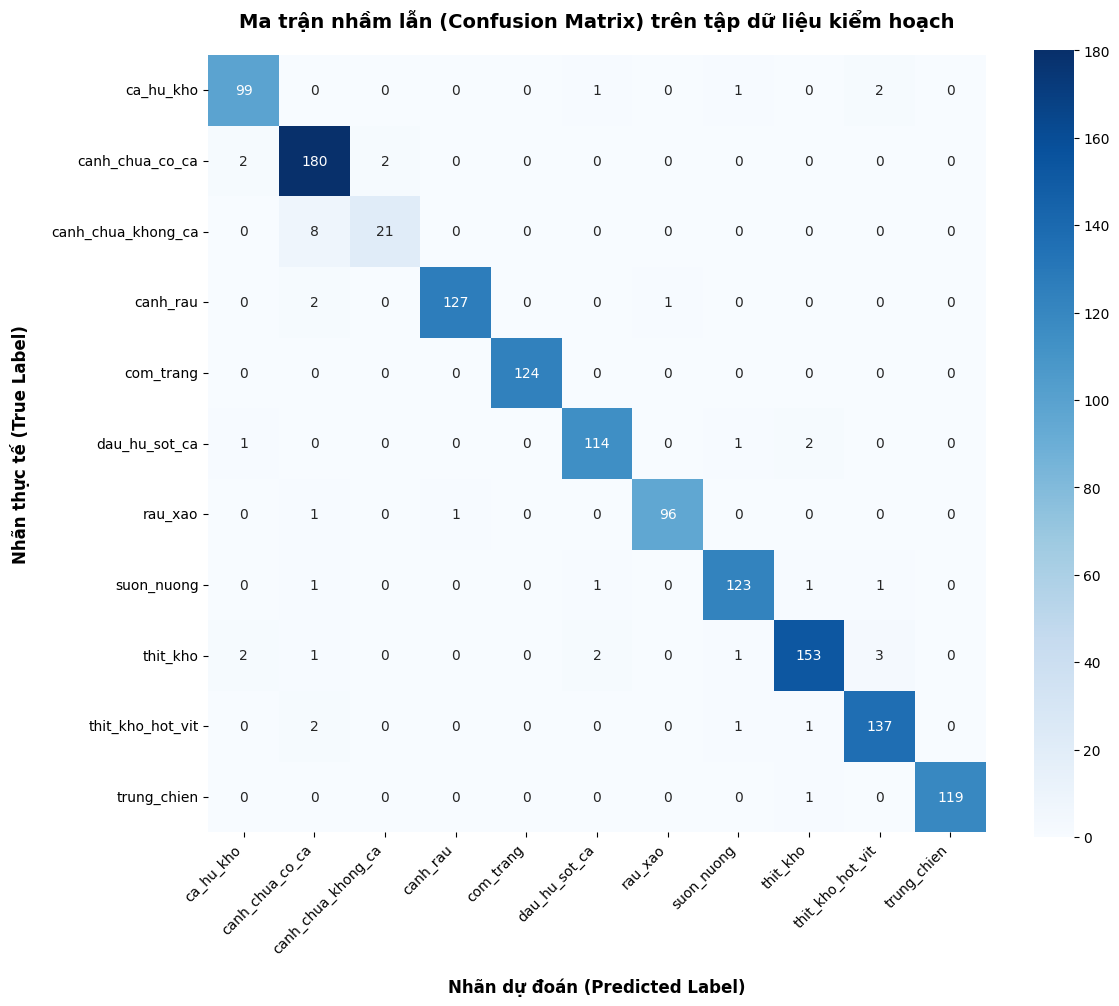


Thành công! Đã xuất xong file ảnh 'confusion_matrix_11x11.png'. Bạn hãy tải từ thanh quản lý file bên trái về máy tính.


In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os

# ==========================================
# 1. KHAI BÁO LẠI CÁC THÔNG SỐ CƠ BẢN
# ==========================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATA_DIR = "/content/drive/MyDrive/AI"  # Đảm bảo bạn đã Mount Drive rồi nhé

# ==========================================
# 2. ĐỊNH NGHĨA LẠI TẬP VAL (ĐÃ SỬA LỖI CLASS_NAMES)
# ==========================================
val_dataset = image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="validation", seed=42,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical',
    crop_to_aspect_ratio=True
)

# Lấy tên các lớp TRƯỚC KHI thực hiện prefetch để tránh lỗi AttributeError
class_names = val_dataset.class_names

# Thực hiện cấu hình tối ưu bộ nhớ sau
AUTOTUNE = tf.data.AUTOTUNE
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)

# ==========================================
# 3. TẢI LẠI MÔ HÌNH ĐÃ TRAIN
# ==========================================
# Gọi lại file mô hình tốt nhất mà bạn đã train xong trước đó
model = tf.keras.models.load_model("/content/final_food_model.keras")

# ==========================================
# 4. DỰ ĐOÁN VÀ VẼ MA TRẬN NHẦM LẪN
# ==========================================
y_true = []
y_pred = []

print("Đang tiến hành dự đoán trên tập Validation (1336 files)...")
for images, labels in val_dataset:
    preds = model.predict(images, verbose=0)
    # Lấy chỉ số (index) của lớp có xác suất cao nhất
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Tính ma trận nhầm lẫn
cm = confusion_matrix(y_true, y_pred)

# Vẽ biểu đồ bằng Seaborn Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,            # Hiện số lượng mẫu vào từng ô
    fmt='d',               # Định dạng số nguyên
    cmap='Blues',          # Tông màu xanh dương
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True,
    square=True            # Giữ các ô vuông vắn
)

# Thêm tiêu đề và cấu hình các trục rõ ràng để chèn báo cáo
plt.title('Ma trận nhầm lẫn (Confusion Matrix) trên tập dữ liệu kiểm hoạch', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Nhãn dự đoán (Predicted Label)', fontsize=12, fontweight='bold', labelpad=15)
plt.ylabel('Nhãn thực tế (True Label)', fontsize=12, fontweight='bold', labelpad=15)

# Xoay chữ trục X 45 độ để tên 11 món ăn không bị đè lên nhau
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()

# Lưu ảnh chất lượng cao 300 DPI để mang đi in ấn không bị mờ
plt.savefig('confusion_matrix_11x11.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nThành công! Đã xuất xong file ảnh 'confusion_matrix_11x11.png'. Bạn hãy tải từ thanh quản lý file bên trái về máy tính.")